# Solutions · 02 · Steam and power cycles

Worked solutions to the exercises of [notebook 02](../notebooks/02_steam_and_power_cycles.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import cycles, steam
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

Plot the thermal efficiency and the exit quality of the simple cycle (3 MPa, 350 degC) against the condenser pressure from 5 to 100 kPa. Why do power plants go to such lengths to keep the condenser cold?

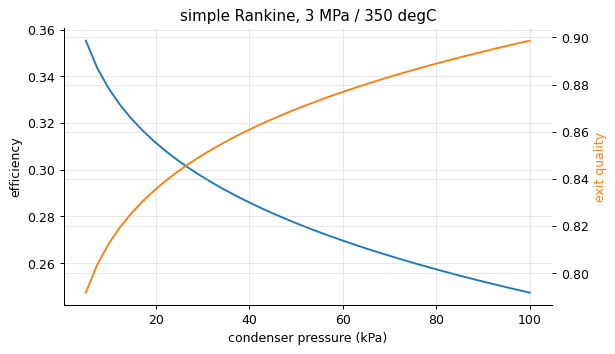

5 kPa: efficiency 35.5%, quality 0.792; 100 kPa: 24.7%, 0.899


In [2]:
p_cond = np.linspace(5e3, 100e3, 40)
res = [cycles.rankine(3e6, p, T_inlet=623.15) for p in p_cond]
fig, a1 = plt.subplots()
a1.plot(p_cond / 1e3, [r["efficiency"] for r in res], "C0"); a1.set(xlabel="condenser pressure (kPa)", ylabel="efficiency", title="simple Rankine, 3 MPa / 350 degC")
a2 = a1.twinx(); a2.plot(p_cond / 1e3, [r["exit_quality"] for r in res], "C1"); a2.set_ylabel("exit quality", color="C1"); plt.show()
print(f"5 kPa: efficiency {res[0]['efficiency']:.1%}, quality {res[0]['exit_quality']:.3f}; 100 kPa: {res[-1]['efficiency']:.1%}, {res[-1]['exit_quality']:.3f}")

Every kilopascal of condenser pressure counts: from 100 to 5 kPa the efficiency rises by about eleven points -
the biggest single lever in the cycle - because the saturation temperature of the condensing steam falls from
100 to 33 degC. The cost is a wetter turbine exhaust (and the cooling water to reach such a low temperature),
which is why plants add superheat and reheat.

## Exercise 2

For the 15 MPa / 600 degC cycle, vary the reheat pressure from 1 to 8 MPa. Where is the efficiency highest, and what happens to the exit quality?

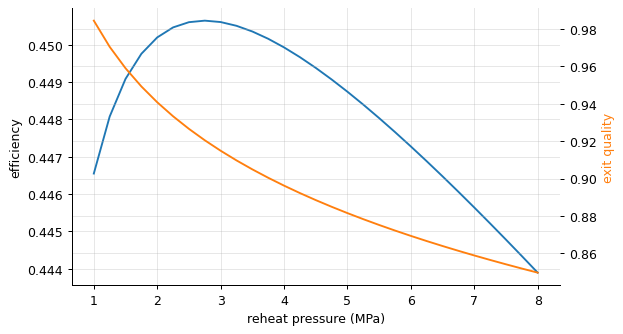

highest efficiency 45.06% at a reheat pressure of 2.8 MPa (exit quality 0.920)


In [3]:
p_rh = np.linspace(1e6, 8e6, 29)
res = [cycles.rankine(15e6, 10e3, T_inlet=873.15, reheat=(p, 873.15)) for p in p_rh]
fig, a1 = plt.subplots()
a1.plot(p_rh / 1e6, [r["efficiency"] for r in res], "C0"); a1.set(xlabel="reheat pressure (MPa)", ylabel="efficiency")
a2 = a1.twinx(); a2.plot(p_rh / 1e6, [r["exit_quality"] for r in res], "C1"); a2.set_ylabel("exit quality", color="C1"); plt.show()
i = int(np.argmax([r["efficiency"] for r in res]))
print(f"highest efficiency {res[i]['efficiency']:.2%} at a reheat pressure of {p_rh[i]/1e6:.1f} MPa (exit quality {res[i]['exit_quality']:.3f})")

The efficiency is a flat maximum near a fifth of the boiler pressure (the usual rule of thumb says a quarter;
the maximum is so flat that either is right), while the exit quality keeps improving as the reheat pressure
rises. Designers pick the reheat pressure to satisfy
the moisture limit, and the efficiency barely notices.

## Exercise 3

**Implement it yourself:** compute the simple Rankine cycle's efficiency from the four state enthalpies using only `steam.two_phase`, `steam.properties`, `steam.state_ps` and `steam.state_ph`, and compare with `cycles.rankine`.

In [4]:
s1 = steam.two_phase(0.0, p=75e3)
s2 = steam.state_ph(3e6, s1["h"] + (steam.state_ps(3e6, s1["s"])["h"] - s1["h"]))
s3 = steam.properties(623.15, 3e6)
s4 = steam.state_ps(75e3, s3["s"])
eta = ((s3["h"] - s4["h"]) - (s2["h"] - s1["h"])) / (s3["h"] - s2["h"])
print(f"by hand: efficiency {eta:.4f};  library: {cycles.rankine(3e6, 75e3, T_inlet=623.15)['efficiency']:.4f}")

by hand: efficiency 0.2602;  library: 0.2602


Four state functions and one formula reproduce the library exactly - the cycle calculation is nothing more
than the steam tables applied at four points.